<a href="https://colab.research.google.com/github/koshaantala/IRIS_NN/blob/main/IRISNeuralNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)


Test Accuracy: 100.00%


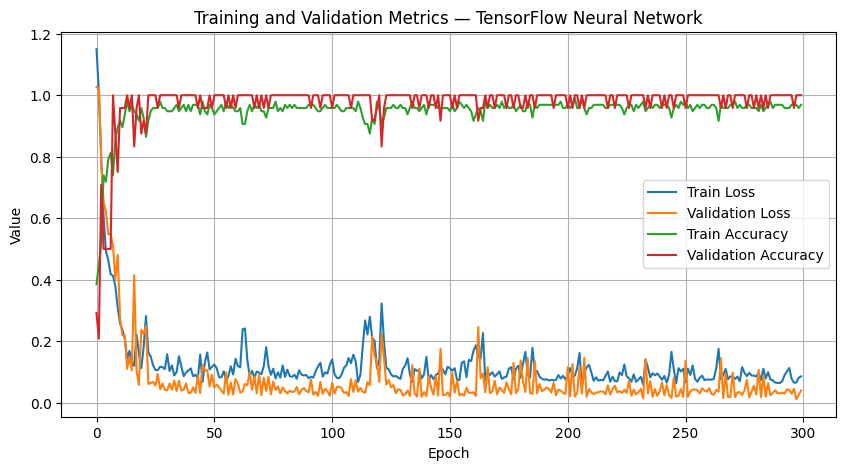

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


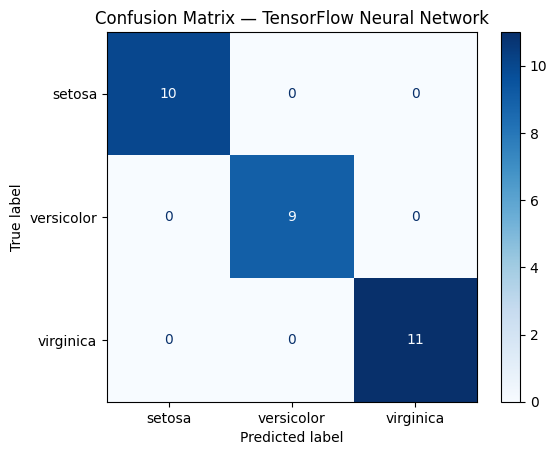

Model saved as 'iris_nn.keras'


In [7]:

# Iris Neural Network Classifier

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Load and preprocess data
data = load_iris()
X = data.data
y = data.target.reshape(-1, 1)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


# Build neural network
model = Sequential([
    Input(shape=(4,), name='Input_Layer'),
    Dense(8, activation='sigmoid', name='Hidden_Layer_1'),
    Dense(6, activation='sigmoid', name='Hidden_Layer_2'),
    Dense(3, activation='softmax', name='Output_Layer')
])


# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
print("\nModel Summary:")
model.summary()


# Train model
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    verbose=0  # set to 1 if you want to see progress
)


# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")


# Plot training history
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Metrics — TensorFlow Neural Network")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


# Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
conf_mat = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=data.target_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — TensorFlow Neural Network")
plt.show()


# Save model
model.save("iris_nn.keras")
print("Model saved as 'iris_nn.keras'")
